In [11]:
!python --version

Python 3.11.11


In [12]:
!pip show numpy

Name: numpy
Version: 2.2.3
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2024, NumPy Developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are
 met:

     * Redistributions of source code must retain the above copyright
        notice, this list of conditions and the following disclaimer.

     * Redistributions in binary form must reproduce the above
        copyright notice, this list of conditions and the following
        disclaimer in the documentation and/or other materials provided
        with the distribution.

     * Neither the name of the NumPy Developers nor the names of any
        contributors may be used to endorse or promote products derived
        from this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED

In [13]:
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import joblib
import warnings

warnings.filterwarnings('ignore')

In [14]:
# Charger les données
data = pd.read_parquet('SBAnational_ML_Dorothee.parquet')

In [15]:
data.head(3)

,Bank,GrAppv,Term,State,ApprovalYear,NAICS_Sectors,New,Franchise,NoEmp,CreateJob,RetainedJob,RevLineCr,LowDoc,Rural,Crisis,PIF
0,FIFTH THIRD BANK,60000,84,IN,1997,45,1.0,0,4,0,0,0.0,1.0,NaN,0,1
1,1ST SOURCE BANK,40000,60,IN,1997,72,1.0,0,2,0,0,0.0,1.0,NaN,0,1
2,GRANT COUNTY STATE BANK,287000,180,IN,1997,62,0.0,0,7,0,0,0.0,0.0,NaN,0,1


In [16]:
dtype_dict = {
    "GrAppv": "float32",
    "Term": "float32",
    "State": "category",
    "NAICS_Sectors": "category",
    "New": "category",
    "Franchise": "category",
    "NoEmp": "float32",
    "RevLineCr": "category",
    "LowDoc": "category",
    "Rural": "category",
    "PIF": "category"
}

data = data.astype(dtype_dict)

In [17]:
data.drop(columns=['Bank', 'ApprovalYear', 'CreateJob', 'RetainedJob', 'Crisis'], inplace=True)

In [18]:
data

,GrAppv,Term,State,NAICS_Sectors,New,Franchise,NoEmp,RevLineCr,LowDoc,Rural,PIF
0,60000.0,84.0,IN,45,1.0,0,4.0,0.0,1.0,NaN,1
1,40000.0,60.0,IN,72,1.0,0,2.0,0.0,1.0,NaN,1
2,287000.0,180.0,IN,62,0.0,0,7.0,0.0,0.0,NaN,1
3,35000.0,60.0,OK,NaN,0.0,0,2.0,0.0,1.0,NaN,1
4,229000.0,240.0,FL,NaN,0.0,0,14.0,0.0,0.0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
899159,70000.0,60.0,OH,45,0.0,0,6.0,NaN,0.0,NaN,1
899160,85000.0,60.0,OH,45,0.0,0,6.0,1.0,0.0,NaN,1
899161,300000.0,108.0,CA,33,0.0,0,26.0,0.0,0.0,NaN,1
899162,75000.0,60.0,HI,NaN,0.0,0,6.0,0.0,1.0,NaN,0


In [19]:
category_columns = ['State', 'NAICS_Sectors', 'New', 'Franchise', 'RevLineCr', 'LowDoc', 'Rural']
numeric_columns = ['Term', 'GrAppv', 'NoEmp']


In [20]:
# Séparer les caractéristiques et la cible
X = data.drop('PIF', axis=1)  # Remplacez 'PIF' par le nom de votre colonne cible
y = data['PIF']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
# Définir le prétraitement pour chaque type de variable
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('encoder', OneHotEncoder(handle_unknown='ignore'))  # Encodage des variables catégorielles
        ]), category_columns)
    ],
    remainder='passthrough')

# Définir le modèle LightGBM
lgbm_model = lgb.LGBMClassifier(objective='binary', metric='auc', boosting_type='gbdt')

# Créer la pipeline complète avec prétraitement et modèle
pipeline = Pipeline([
    ('preprocessor', preprocessor),  # Prétraitement des données
    ('lgbm', lgbm_model)             # Modèle LightGBM
])



In [22]:
best_params =  {'lambda_l1': 6.907842886583572e-08, 'lambda_l2': 1.703188073401647e-05, 'num_leaves': 89, 'learning_rate': 0.09465740365801667, 'feature_fraction': 0.7413758923232424, 'bagging_fraction': 0.4785259788366699, 'bagging_freq': 4, 'min_child_samples': 76}

In [23]:
# Définir les meilleurs hyperparamètres trouvés par Optuna
best_params = best_params

# Mettre à jour les noms des paramètres pour qu'ils correspondent à ceux attendus par le pipeline
best_params = {f'lgbm__{key}': value for key, value in best_params.items()}

# Appliquer les meilleurs hyperparamètres au pipeline
pipeline.set_params(**best_params)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['State', 'NAICS_Sectors',
                                                   'New', 'Franchise',
                                                   'RevLineCr', 'LowDoc',
                                                   'Rural'])])),
                ('lgbm',
                 LGBMClassifier(bagging_fraction=0.4785259788366699,
                                bagging_freq=4,
                                feature_fraction=0.7413758923232424,
                                lambda_l1=6.907842886583572e-08,
                                lambda_l2=1.703188073401647e-05,
                                learning_rate=0.09465740365801667, metric='auc',
                                min_child_samples=76, num_leaves=89,
                                objective='binary'))])

In [24]:
pipeline.fit(X_train, y_train)

[LightGBM] [Warning] feature_fraction is set=0.7413758923232424, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7413758923232424
[LightGBM] [Warning] lambda_l2 is set=1.703188073401647e-05, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.703188073401647e-05
[LightGBM] [Warning] lambda_l1 is set=6.907842886583572e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=6.907842886583572e-08
[LightGBM] [Warning] bagging_fraction is set=0.4785259788366699, subsample=1.0 will be ignored. Current value: bagging_fraction=0.4785259788366699
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] feature_fraction is set=0.7413758923232424, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7413758923232424
[LightGBM] [Warning] lambda_l2 is set=1.703188073401647e-05, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.703188073401647e-05
[LightGBM] [Warnin

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['State', 'NAICS_Sectors',
                                                   'New', 'Franchise',
                                                   'RevLineCr', 'LowDoc',
                                                   'Rural'])])),
                ('lgbm',
                 LGBMClassifier(bagging_fraction=0.4785259788366699,
                                bagging_freq=4,
                                feature_fraction=0.7413758923232424,
                                lambda_l1=6.907842886583572e-08,
                                lambda_l2=1.703188073401647e-05,
                                learning_rate=0.09465740365801667, metric='auc',
                                min_child_samples=76, num_leaves=89,
                                objective='binary'))])

In [25]:
# Save the pipeline
import pickle

with open("final_model_pipeline.pkl", "wb") as fichier:
    pickle.dump(pipeline, fichier)

In [26]:
# Predictions and evaluation
y_pred_proba = pipeline.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

[LightGBM] [Warning] feature_fraction is set=0.7413758923232424, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7413758923232424
[LightGBM] [Warning] lambda_l2 is set=1.703188073401647e-05, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.703188073401647e-05
[LightGBM] [Warning] lambda_l1 is set=6.907842886583572e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=6.907842886583572e-08
[LightGBM] [Warning] bagging_fraction is set=0.4785259788366699, subsample=1.0 will be ignored. Current value: bagging_fraction=0.4785259788366699
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4


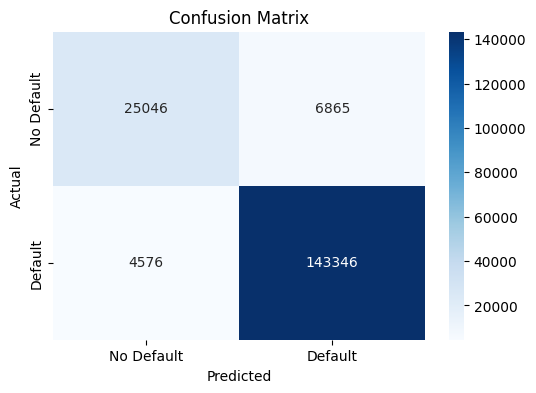

In [27]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

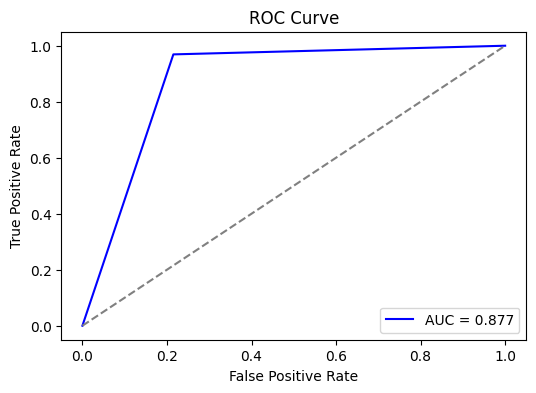

In [28]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [29]:
# Feature Importance

lgb.plot_importance(pipeline.named_steps['lgbm'], max_num_features=10, importance_type='gain')
plt.title('Top 10 Feature Importances')
plt.show()

print(f'Final Model Accuracy: {accuracy_score(y_test, y_pred):.3f}')

ImportError: You must install matplotlib and restart your session to plot importance.

In [ ]:
some_data = data.iloc[:5]
some_data.to_csv('some_data.csv', index=False)

In [ ]:
some_data

In [ ]:
X_test.info()

In [ ]:
predict_antoine = X_test[:1]

In [ ]:
predict_antoine

In [ ]:
pipeline.predict(predict_antoine)